In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.config import DADOS_TRATADOS
from src.auxiliares import dataframe_coeficientes
from src.graficos import plot_coeficientes, plot_residuos


sns.set_theme(palette="bright")

RANDOM_STATE = 42

In [9]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [10]:
df["sexo"] = df["sexo"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   idade             442 non-null    int8    
 1   sexo              442 non-null    category
 2   imc               442 non-null    float32 
 3   pressao_media     442 non-null    float32 
 4   colesterol_total  442 non-null    int16   
 5   ldl               442 non-null    float32 
 6   hdl               442 non-null    float32 
 7   colesterol_hdl    442 non-null    float32 
 8   triglicerides     442 non-null    float32 
 9   glicose           442 non-null    int8    
 10  target            442 non-null    int16   
dtypes: category(1), float32(6), int16(2), int8(2)
memory usage: 13.6 KB


A técnica de One-Hot Encoding é amplamente utilizada em machine learning e processamento de dados para converter variáveis categóricas em uma forma que possa ser utilizada por algoritmos de aprendizado de máquina, que geralmente requerem dados numéricos.

### O Problema das Variáveis Categóricas

Muitas vezes, conjuntos de dados contêm variáveis categóricas, ou seja, variáveis que representam categorias distintas, como "cor", "tipo de produto", "gênero", entre outros. Essas categorias não possuem uma ordem intrínseca e, portanto, não podem ser diretamente tratadas como valores numéricos. No entanto, a maioria dos algoritmos de machine learning trabalha com números, e alimentar categorias diretamente como números pode induzir o algoritmo a inferir uma ordem ou relação numérica que não existe.

### O Conceito de One-Hot Encoding

One-Hot Encoding resolve esse problema ao transformar cada categoria em uma nova variável binária (coluna), onde cada coluna representa uma categoria única da variável original. Se a instância da variável pertence a essa categoria, a coluna correspondente recebe o valor 1, caso contrário, recebe o valor 0.

### Exemplo

Considere uma variável categórica simples que indica a cor de um objeto com três possíveis valores: "Vermelho", "Verde" e "Azul". Usando One-Hot Encoding, essa variável categórica seria transformada em três colunas, uma para cada cor:



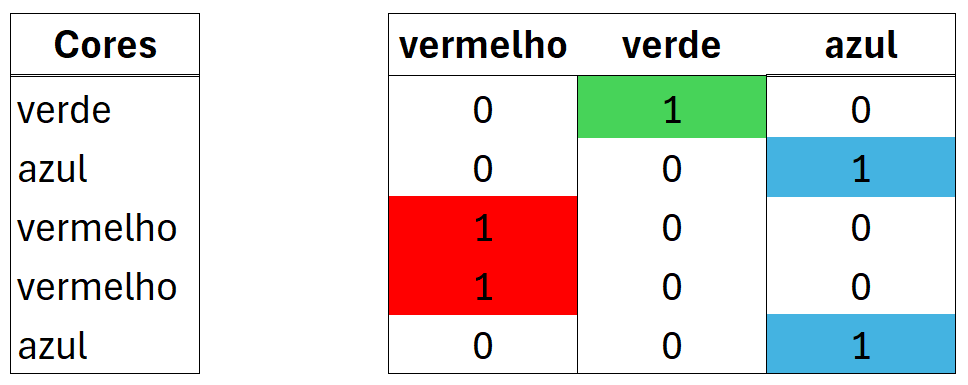


Nesse formato, cada categoria da variável original é representada de maneira independente, evitando que o modelo interprete erroneamente a ordem ou a proximidade entre as categorias.

### Vantagens do One-Hot Encoding

- **Neutralidade de Ordens**: Não impõe nenhuma ordem entre as categorias, evitando interpretações errôneas por parte dos modelos.
- **Compatibilidade**: A maioria dos algoritmos de machine learning pode processar esses dados, uma vez que se tornam numéricos.

### Desvantagens do One-Hot Encoding

- **Alta Dimensionalidade**: Se uma variável categórica tiver muitas categorias, One-Hot Encoding pode gerar um grande número de novas colunas, aumentando a dimensionalidade do conjunto de dados e potencialmente levando a problemas de desempenho e complexidade.
- **Espaço de Memória**: Em casos de conjuntos de dados muito grandes ou com muitas categorias, o armazenamento das matrizes resultantes pode consumir muita memória.

### Aplicações e Considerações

One-Hot Encoding é especialmente útil em modelos de classificação e regressão, onde a neutralidade da representação categórica é crítica. No entanto, quando se lida com variáveis categóricas de alta cardinalidade (muitas categorias), técnicas alternativas podem ser mais adequadas para evitar a explosão combinatorial de colunas.


In [ ]:
#Ele espera receber uma lista de tuplas, como o pipeline

In [ ]:
#E por padrão as colunas que a gente não apontar ele vai dropar elas que é remainder que por padrão é "drop"

In [ ]:
#Nesse caso como esse dataframe só tem uma coluna categorica e só tem duas categorias eu posso usar o parametro if_binary

In [ ]:
"""
drop{‘first’, ‘if_binary’} or an array-like of shape (n_features,), default=None
Specifies a methodology to use to drop one of the categories per feature. This is useful in situations where perfectly collinear features cause problems, such as when feeding the resulting data into an unregularized linear regression model.

However, dropping one category breaks the symmetry of the original representation and can therefore induce a bias in downstream models, for instance for penalized linear classification or regression models.

None : retain all features (the default).

‘first’ : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.

‘if_binary’ : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.

array : drop[i] is the category in feature X[:, i] that should be dropped.

When max_categories or min_frequency is configured to group infrequent categories, the dropping behavior is handled after the grouping.
"""

In [11]:
X = df.drop(columns = "target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = RANDOM_STATE
)#vamos separar o que é treino e teste

In [14]:
pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([ #São Transformações de colunas em numericos e categoricos 
        ("numeric", StandardScaler(), X.select_dtypes(include = "number").columns),
        ("categoric", OneHotEncoder(drop = "if_binary"), ["sexo"])
    ])),
    ("reg", LinearRegression())#Aplicando o modelo de regressão
])

pipeline # Quando você clica no i parece fitted porque você não ajustou seus dados

,steps,"[('preprocessor', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categoric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
pipeline.fit(X_train, y_train)# Quando você clica no i parece fitted porque você ajustou seus dados

,steps,"[('preprocessor', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categoric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#Vizualizando o OHE

In [16]:
pipeline.named_steps

{'preprocessor': ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                  Index(['idade', 'imc', 'pressao_media', 'colesterol_total', 'ldl', 'hdl',
        'colesterol_hdl', 'triglicerides', 'glicose'],
       dtype='object')),
                                 ('categoric', OneHotEncoder(drop='if_binary'),
                                  ['sexo'])]),
 'reg': LinearRegression()}

In [17]:
pipeline["reg"].coef_

array([  1.75375723,  25.60712087,  16.82887089, -44.44885934,
        24.64095583,   7.67697872,  13.13878389,  35.16119782,
         2.35136418, -23.06446729])

In [18]:
pipeline["reg"].intercept_    

np.float64(164.5827227571263)

In [19]:
pipeline["preprocessor"]

,transformers,"[('numeric', ...), ('categoric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [ ]:
#Pode avaliar o que entrou e o que saiu dessa entrada

In [22]:
pipeline["preprocessor"].feature_names_in_

array(['idade', 'sexo', 'imc', 'pressao_media', 'colesterol_total', 'ldl',
       'hdl', 'colesterol_hdl', 'triglicerides', 'glicose'], dtype=object)

In [23]:
pipeline["preprocessor"].get_feature_names_out()

array(['numeric__idade', 'numeric__imc', 'numeric__pressao_media',
       'numeric__colesterol_total', 'numeric__ldl', 'numeric__hdl',
       'numeric__colesterol_hdl', 'numeric__triglicerides',
       'numeric__glicose', 'categoric__sexo_2'], dtype=object)

In [ ]:
#Ele faz isso numeric__idade para separar os diferentes tratamentos do numeric e do category

In [24]:
coefs = dataframe_coeficientes(
    pipeline["reg"].coef_,
    pipeline["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
numeric__colesterol_total,-44.448859
categoric__sexo_2,-23.064467
numeric__idade,1.753757
numeric__glicose,2.351364
numeric__hdl,7.676979
numeric__colesterol_hdl,13.138784
numeric__pressao_media,16.828871
numeric__ldl,24.640956
numeric__imc,25.607121
numeric__triglicerides,35.161198


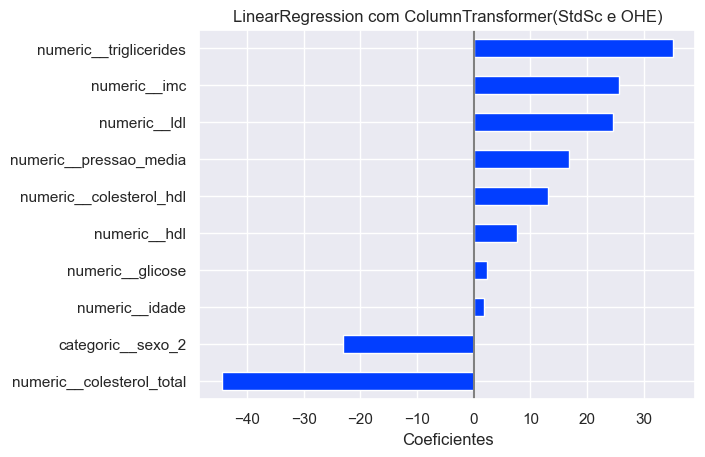

In [26]:
plot_coeficientes(coefs, "LinearRegression com ColumnTransformer(StdSc e OHE)")

In [ ]:
#VOcê percebe que a coluna categorica sexo teve um aumnento no coeficiente

In [29]:
pipeline["preprocessor"]["categoric"].transform(X[["sexo"]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 207 stored elements and shape (442, 1)>

In [ ]:
#Ou seja ele so guardou as posições que ten 1 ou seja as que são presentes que não for um vai ser o outro então ou seria duas colunas virou apenas uma

In [33]:
X["sexo"]

0      2
1      1
2      2
3      1
4      1
      ..
437    2
438    2
439    2
440    1
441    1
Name: sexo, Length: 442, dtype: category
Categories (2, int8): [1, 2]

In [32]:
pipeline["preprocessor"]["categoric"].transform(X[["sexo"]]).toarray()

array([[1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],

In [ ]:
#Avaliando métricas

In [ ]:
#Se teve alguma mudança significativa

In [34]:
y_pred = pipeline.predict(X_test)

In [35]:
mean_absolute_error(y_test, y_pred)

42.79409657680721

In [36]:
mean_squared_error(y_test, y_pred)

2900.19385161844

In [37]:
root_mean_squared_error(y_test, y_pred)

53.85344790835996

In [38]:
r2_score(y_test, y_pred)

0.4526027208581844

In [ ]:
#Se viu que não teve muito mudança que trouxe algo significativo, basicamente são os mesmos valores

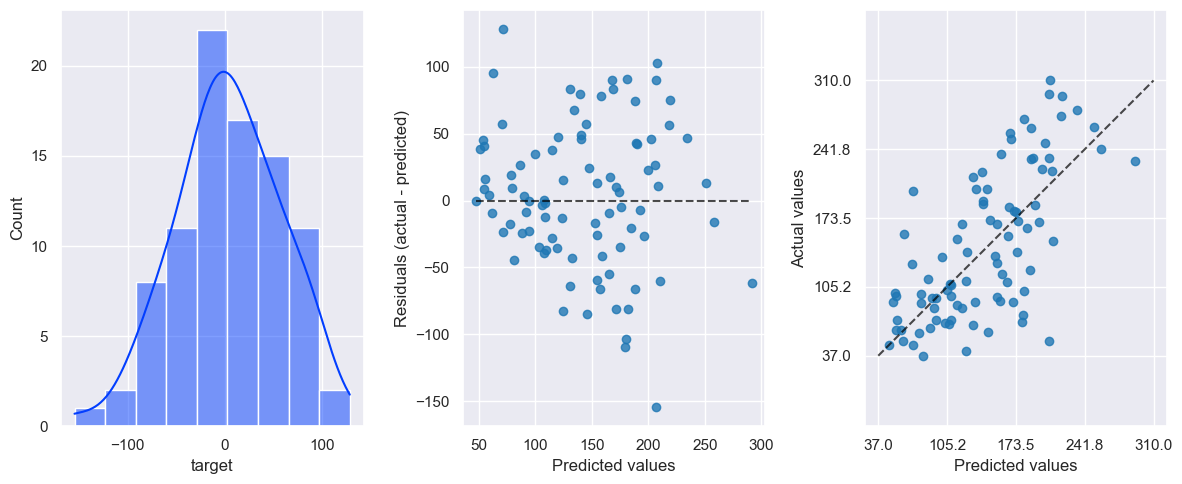

In [39]:
plot_residuos(y_test, y_pred)

In [ ]:
#Mostrando outros Scalers e Transformers

In [ ]:
"""StandardScaler A transformação remove a média e ajusta a escala dos dados para variância unitária. 
Esse ajuste reduz a amplitude dos valores das variáveis, como mostrado na figura à esquerda abaixo. 
No entanto, os outliers influenciam o cálculo da média e do desvio padrão empíricos. 
Observe, em particular, que, como os outliers em cada variável têm magnitudes diferentes, 
a dispersão dos dados transformados em cada variável é muito diferente: a maior parte dos dados se encontra no intervalo [-2, 4] para a variável renda mediana transformada, 
enquanto os mesmos dados ficam comprimidos no intervalo menor [-0,2, 0,2] para a variável ocupação média de residências transformada."""

In [ ]:
"""
PowerTransformerAplica uma transformação de potência a cada característica para tornar os dados mais semelhantes a uma distribuição gaussiana, 
a fim de estabilizar a variância e minimizar a assimetria. Atualmente, as transformações de Yeo-Johnson e Box-Cox são suportadas, 
e o fator de escala ideal é determinado por meio da estimativa de máxima verossimilhança em ambos os métodos. 
Por padrão, PowerTransformeraplica-se a normalização com média zero e variância unitária. 
Observe que a transformação de Box-Cox só pode ser aplicada a dados estritamente positivos. 
A renda e a ocupação média de residências são exemplos de dados estritamente positivos, mas, 
se houver valores negativos, a transformação de Yeo-Johnson é preferível."""

In [ ]:
#A maioria dos modelos esperam que as Features com a mesma escala e que seguem uma distriubuição normal

In [ ]:
"""A transformação de potência é útil na modelagem de problemas onde se desejam homocedasticidade e normalidade. Abaixo, seguem exemplos da aplicação dos métodos Box-Cox e Yeo-Johnwon a seis distribuições de probabilidade diferentes: Lognormal, Qui-quadrado, Weibull, Gaussiana, Uniforme e Bimodal.

Note que as transformações mapeiam com sucesso os dados para uma distribuição normal quando aplicadas a certos conjuntos de dados, mas são ineficazes com outros. Isso destaca a importância de visualizar os dados antes e depois da transformação.

Observe também que, embora o método Box-Cox pareça ter um desempenho melhor do que o método Yeo-Johnson para distribuições lognormais e qui-quadrado, lembre-se de que o método Box-Cox não suporta entradas com valores negativos.

Para comparação, adicionamos também a saída de QuantileTransformer. Ela pode forçar qualquer distribuição arbitrária a se tornar gaussiana, desde que haja amostras de treinamento suficientes (milhares). Por ser um método não paramétrico, sua interpretação é mais complexa do que a dos métodos paramétricos (Box-Cox e Yeo-Johnson).

Em conjuntos de dados "pequenos" (menos de algumas centenas de pontos), o transformador quantílico é propenso a sobreajuste. Nesses casos, recomenda-se o uso da transformação de potência."""

In [ ]:
#Criando uma nova coluna e avaliando transformações